# Folketinget Speeches - Topic Modeling Analysis
### Proof of concept for nlp exam

This notebook performs BERTTopic analysis on Danish parliamentary speeches (2020-2022) to identify main topics and compare topic emphasis across political parties.

## 1. Loading packages

In [1]:
import sys
sys.path.append('/work/Exam/src') # setting path to our src so we can easily load in our functions

# own functions
from data_load import load_data, filter_data, sample_speeches
from stopwords import get_stopwords
from topic_model import train_bertopic, create_topic_labels
from exploration import explore_data, plot_temporal_distribution, plot_party_distribution
from plotting import prepare_analysis_data, create_all_visualizations

import pandas as pd

/work/Exam/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.1 Configs

In [2]:
# running configs
CONFIG = {
    'data_path': '/work/Exam/data/Corpus_speeches_denmark.RDS',
    'start_year': 2020,
    'end_year': 2022,
    'min_text_length': 100, # might increase this higher than 100 later. a speech of a 100 letters is not long at all
    'sample_size': 20000, # we keeping it limited for this one
    'nr_topics': 10, # same here
    'min_topic_size': 25, # this is the minimum size of a created topic. when we run the actual analysis, we should increase this number
    'random_state': 69
}

### 1.2. Loading the data and sampling from it

In [3]:
# loading the data
df_raw = load_data(CONFIG['data_path'])
# filtering the data to only keep 2020 -> 2022 and removing speeches under 100 letters.
df_filtered = filter_data(
    df_raw, 
    start_year=CONFIG['start_year'],
    end_year=CONFIG['end_year'],
    min_length=CONFIG['min_text_length']
)

LOADING DATA

Loaded 716,807 speeches
Columns: ['speaker', 'text', 'party', 'date', 'agenda', 'speechnumber', 'procedure_ID', 'partyfacts_ID', 'period', 'chair', 'link']
FILTERING DATA

Original: 716,807 speeches
Filtered: 72,050 speeches (10.1%)
Time period: 2020-2022
Min length: 100 characters
Unique parties: 19


### 1.3. Sampling the data

In [4]:
# sampling only 20k speeches (out of the 70k from 2020-2022) to limit the computational load of this
df_sample = sample_speeches(
    df_filtered,
    sample_size=CONFIG['sample_size'],
    random_state=CONFIG['random_state']
)

# append the documents
documents = df_sample['text'].tolist()

SAMPLING THE SPEECHES

Target sample: 20,000 speeches
Sample created: 20,000 speeches

Party distribution in sample:
  S       : 5,280 (26.40%)
  V       : 2,792 (13.96%)
  DF      : 2,345 (11.72%)
  EL      : 1,954 ( 9.77%)
  SF      : 1,670 ( 8.35%)
  RV      : 1,401 ( 7.00%)
  KF      : 1,336 ( 6.68%)
  NB      : 1,282 ( 6.41%)
  LA      :   656 ( 3.28%)
  UFG     :   363 ( 1.81%)
  ALT     :   344 ( 1.72%)
  KD      :   179 ( 0.90%)
  FG      :   164 ( 0.82%)
  IA      :    91 ( 0.46%)
  SIU     :    62 ( 0.31%)
  SP      :    47 ( 0.24%)
  DD      :    21 ( 0.10%)
  M       :    11 ( 0.06%)
  JF      :     2 ( 0.01%)


## 2. Data exploration

DATA EXPLORATION

Total speeches: 716,807
Date range: 2007-11-27 00:00:00 to 2022-10-06 00:00:00
Unique parties: 24

Speeches by year:
  2007: 2,918
  2008: 48,854
  2009: 48,428
  2010: 60,035
  2011: 44,525
  2012: 46,760
  2013: 42,496
  2014: 37,388
  2015: 43,104
  2016: 57,082
  2017: 51,028
  2018: 43,069
  2019: 40,146
  2020: 59,450
  2021: 59,771
  2022: 31,753

Top 10 parties:
  -       : 371,386 ( 51.8%)
  S       : 73,317 ( 10.2%)
  V       : 66,970 (  9.3%)
  DF      : 45,887 (  6.4%)
  EL      : 39,173 (  5.5%)
  SF      : 30,574 (  4.3%)
  KF      : 26,930 (  3.8%)
  RV      : 23,367 (  3.3%)
  LA      : 18,602 (  2.6%)
  ALT     :  8,539 (  1.2%)

Chair speeches: 371,386 (51.8%)

Speech length statistics:
  Mean: 627 chars
  Median: 217 chars
  <100 chars: 294,648 (41.1%)


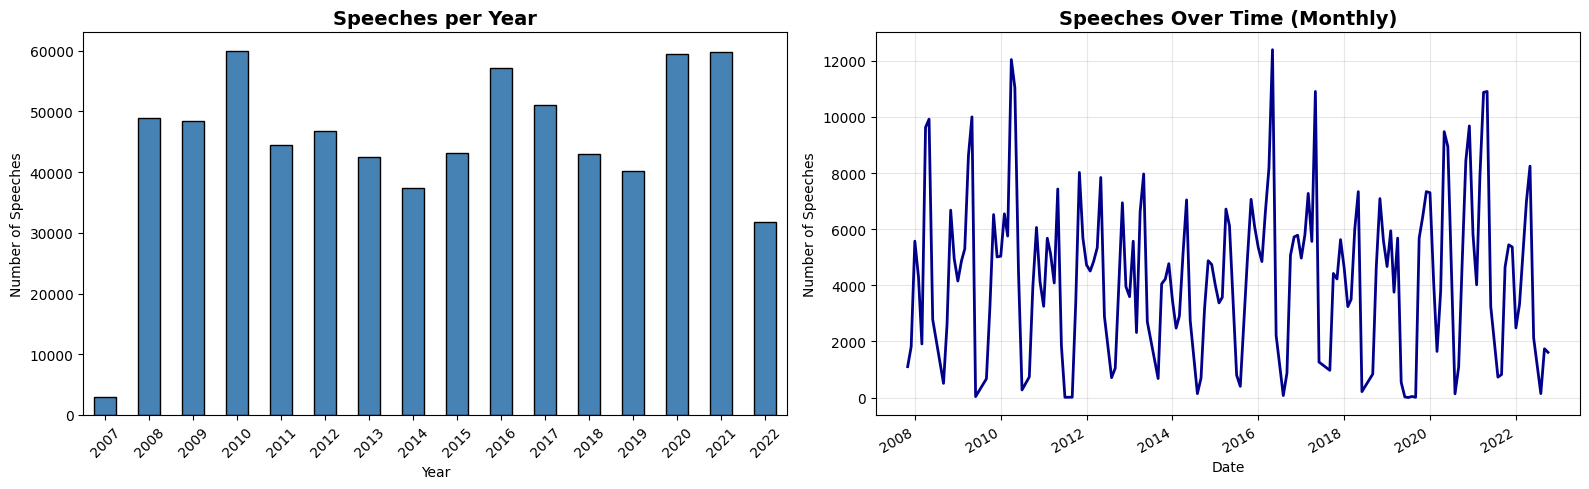

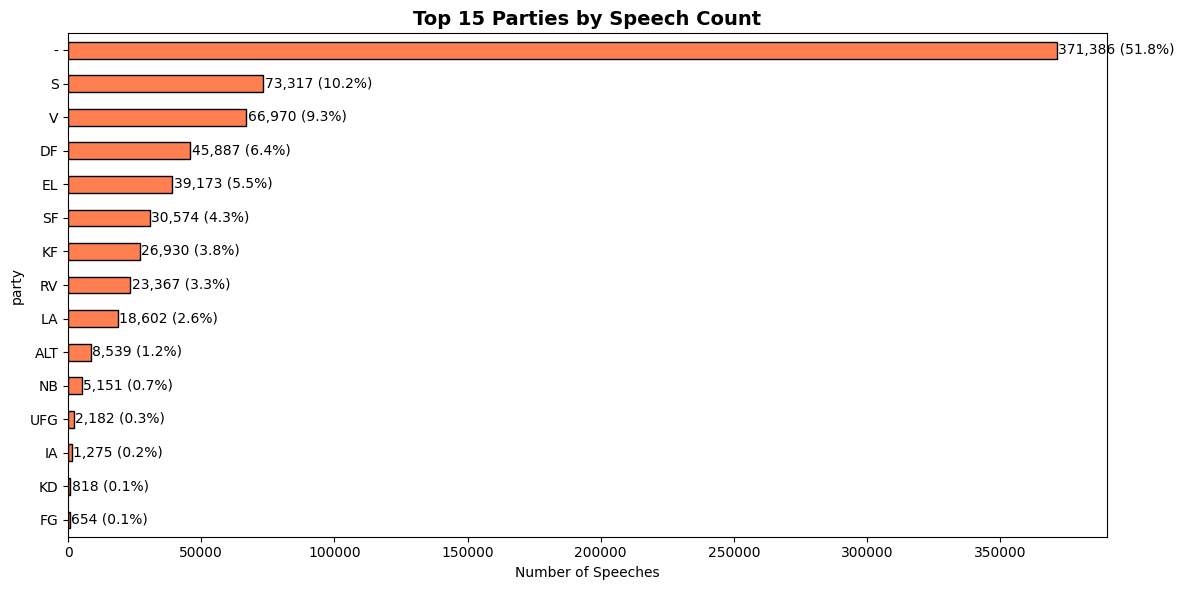

In [5]:
explore_data(df_raw)
plot_temporal_distribution(df_raw)
plot_party_distribution(df_raw)

## 3. Topic modelling

### 3.1. Stopwords

In [6]:
# Getting the stopwords
danish_stopwords = get_stopwords()

Loaded the spacy model: da_core_news_sm
Loaded 219 the stopwords from spacy
Added 26 stopwords
Total stopwords: 245


### 3.2. Training the model

In [7]:
# fitting and training the model. embedding model is paraphrase-multilingual-MiniLM-L12-v2, and we going with mmr of .3
topic_model, topics, probs = train_bertopic(
    documents,
    stopwords=danish_stopwords,
    nr_topics=CONFIG['nr_topics'],
    min_topic_size=CONFIG['min_topic_size']
)

# appending the topics
df_sample['topic'] = topics


Training BERTopic on 20,000 documents...
Config: 10 topics, min_size=25, 245 stopwords


2025-10-30 12:42:13,460 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 625/625 [01:57<00:00,  5.32it/s]
2025-10-30 12:44:11,876 - BERTopic - Embedding - Completed ✓
2025-10-30 12:44:11,879 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-30 12:44:40,320 - BERTopic - Dimensionality - Completed ✓
2025-10-30 12:44:40,322 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-30 12:44:46,176 - BERTopic - Cluster - Completed ✓
2025-10-30 12:44:46,178 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-30 12:44:53,651 - BERTopic - Representation - Completed ✓
2025-10-30 12:44:53,655 - BERTopic - Topic reduction - Reducing number of topics
2025-10-30 12:44:53,678 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-30 12:46:43,022 - BERTopic - Representation - Completed ✓
2025-10-30 12:46:43,033 - BERTopic - Topic reduction - Re

Complete in 4.5 min
   Topics: 10, Outliers: 8706


### 3.3. Creating the labels

In [8]:
# creating the labels
topic_labels = create_topic_labels(topic_model, n_words=4)

# show the topics
topic_info = topic_model.get_topic_info()
print("\nDiscovered Topics:")
for _, row in topic_info[topic_info['Topic'] > 0].head(10).iterrows():
    topic_id = row['Topic']
    label = topic_labels.get(topic_id, f"Topic {topic_id}")
    print(f"  {topic_id}. {label} ({row['Count']} speeches)")


Discovered Topics:
  1. lovforslaget + lovforslag + statsministeren + aftale (2878 speeches)
  2. ældre + læger + arbejdsmarkedet + patienter (891 speeches)
  3. islam + muslimske + syrien + muslimer (813 speeches)
  4. co2 + cigaretter + afgift + cannabis (763 speeches)
  5. naturen + naturnationalparker + vacciner + biodiversitet (507 speeches)
  6. køn + racisme + mænd kvinder + arbejdsmarkedet (296 speeches)
  7. kunstakademiet + kunstneriske + bestyrelser + kulturen (87 speeches)
  8. kød + forbrugerne + fødevarer + religiøse (36 speeches)


## 4. Visualisations

### 4.1. Prepping the topics

In [9]:
# Filter out outliers (-1) and generic topic (0)
df_analysis = prepare_analysis_data(df_sample, topics, topic_labels)


Analysis data prepared:
  Total speeches: 20,000
  Valid for analysis: 6,271
  Topics: 8


### 4.2. Plotting and saving the plots

CREATING VISUALIZATIONS


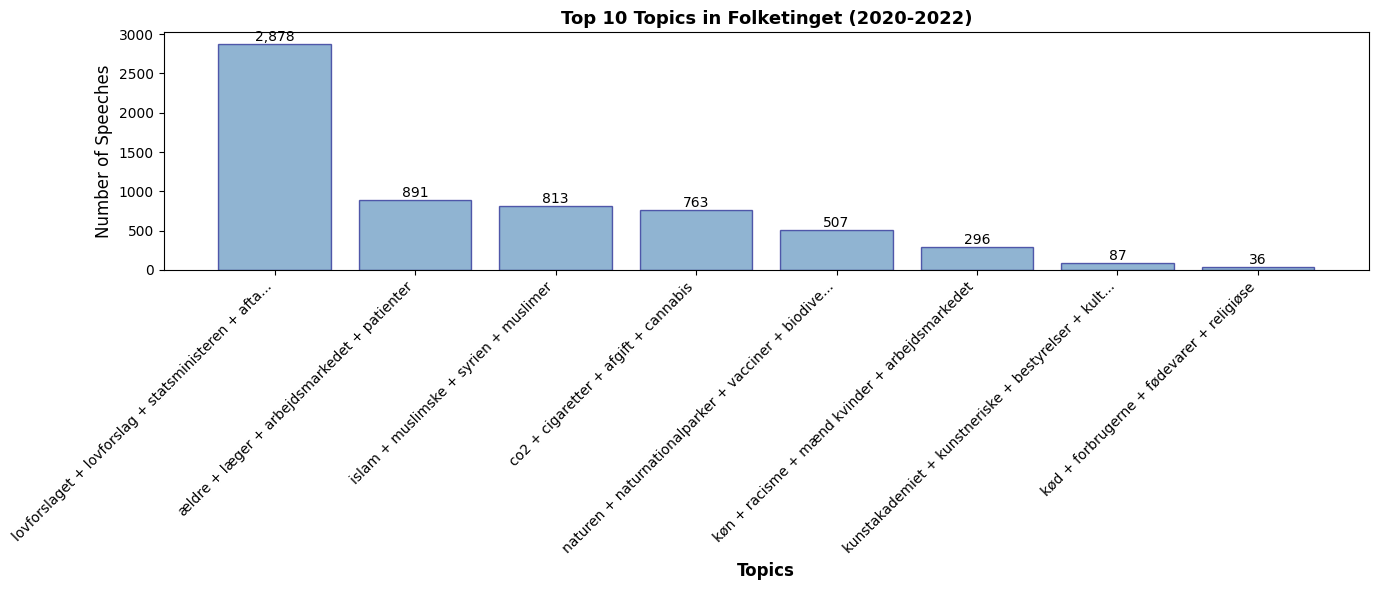

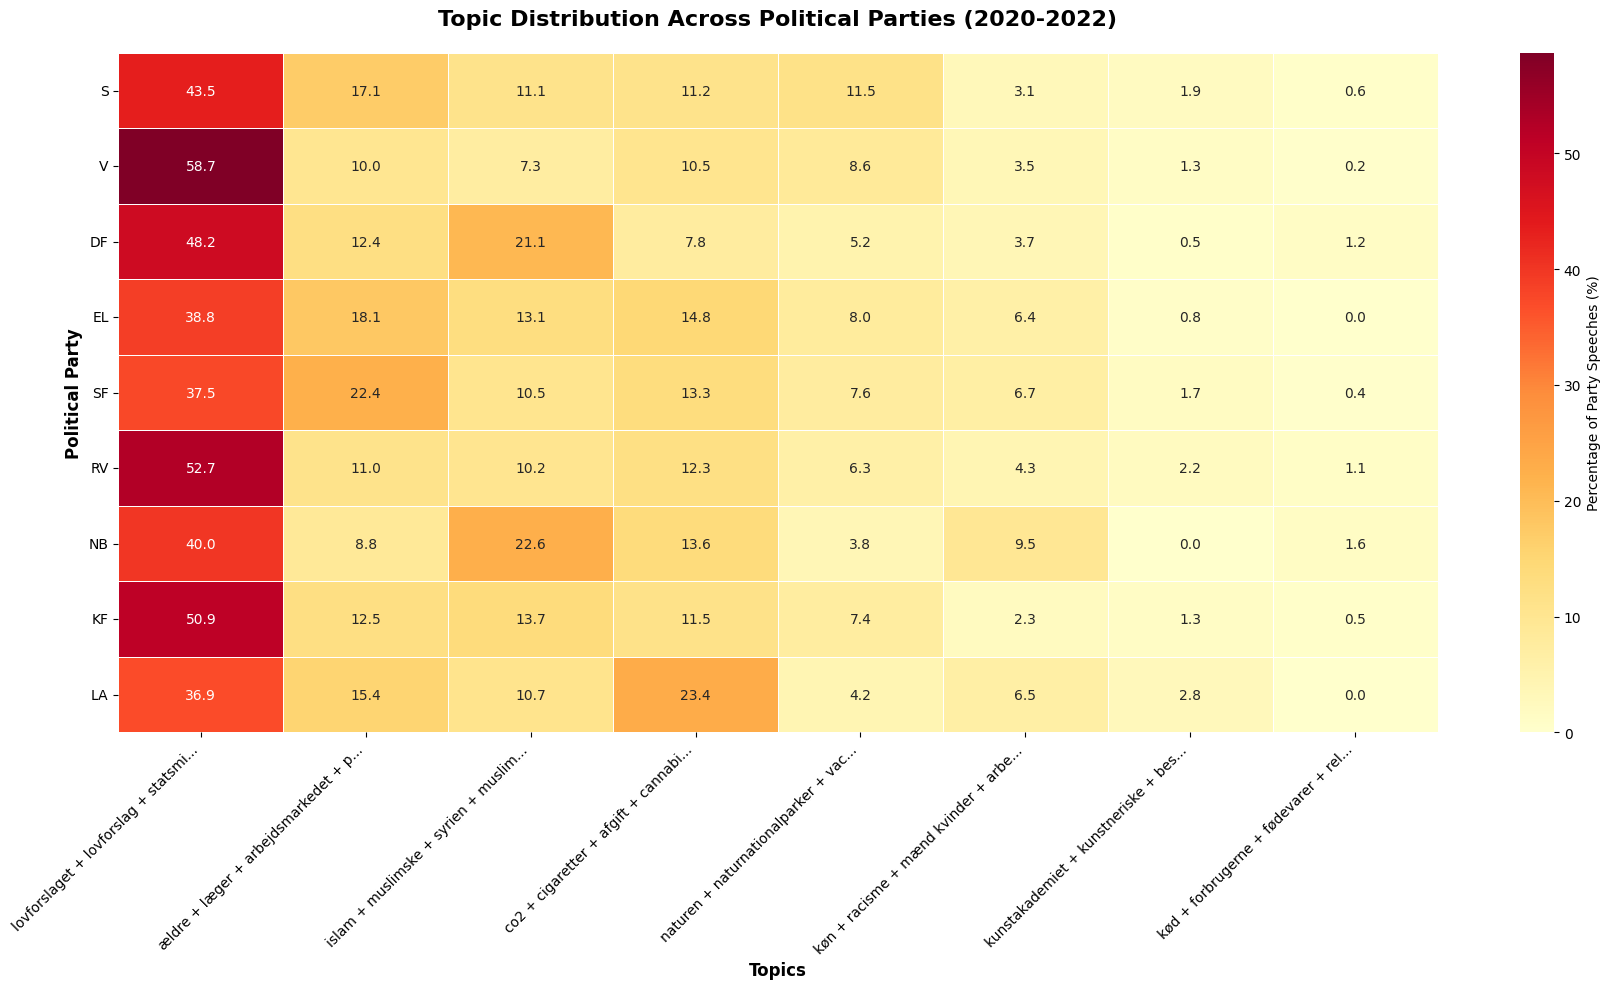

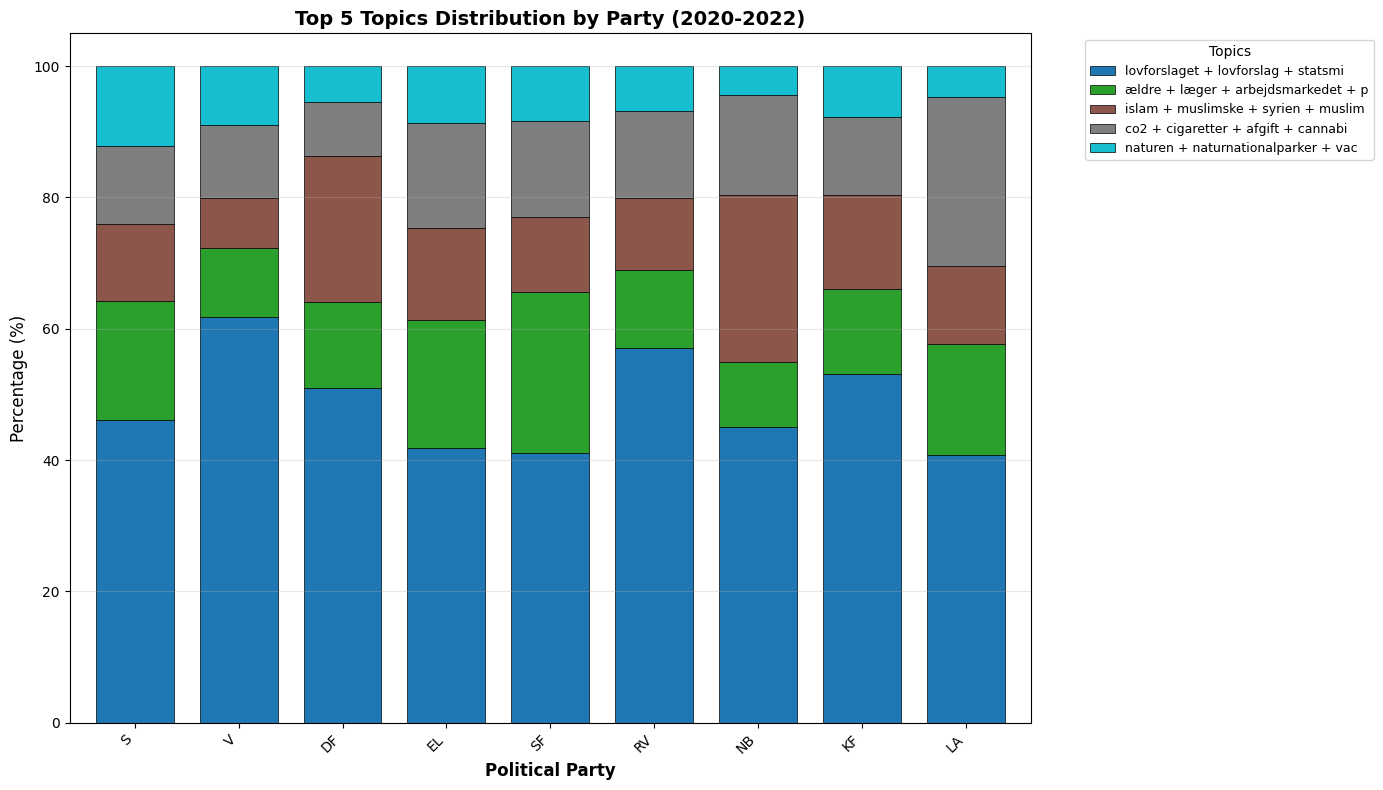

In [10]:
# making plots and saving the data in /out
create_all_visualizations(df_analysis, topic_model, topic_labels, topics)